# 24. 모델 학습 및 하이퍼파라미터 최적화 (README §6)

이 노트북은 README의 6장에 기술된 **UnderBagging Ensemble** 방식과 **다단계 하이퍼파라미터 튜닝** 파이프라인을 실행합니다.

### 실행 단계
1. **데이터 준비**: Full Train (10 Subsets), Full Validation, Sampled Validation 로드
2. **[Optuna Stage 1] 구조적 탐색**: 넓은 탐색 공간, `n_estimators=400` 고정, 적극적 가지치기(Pruning)
3. **[Optuna Stage 2] 정밀 튜닝**: Stage 1 최적값 주변 좁은 탐색 공간, 웜스타트 주입, `n_estimators` 해방
4. **[Reranking] 최종 파라미터 선정**: Sampled 검증셋의 편향 리스크를 줄이기 위해 상위 후보들을 Full Validation으로 재평가
5. **최종 모델 저장**: 산출된 최적 파라미터 및 앙상블 모델을 저장

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath('..'))  # notebooks/ 에서 실행 시

import numpy as np
import pandas as pd

from src.train_core import (
    SubsetTrainer, UnderbaggingEnsemble,
    run_training, print_ensemble_summary, plot_subset_prauc, plot_confusion_matrix
)
import config.train_config as cfg

print('환경 준비 완료')
print(f'TRAIN_PATH    : {cfg.TRAIN_PATH}')
print(f'VAL_TUNE_PATH : {cfg.VAL_TUNE_PATH}')

c:\Workspace\06_ML_projdect\26_1_COIN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🖥️  LightGBM GPU 가용성: [OK] 사용 가능
환경 준비 완료
TRAIN_PATH    : c:\Workspace\06_ML_projdect\26_1_COIN\data\06a_feature_engineering\train.parquet
VAL_TUNE_PATH : c:\Workspace\06_ML_projdect\26_1_COIN\data\06a_feature_engineering\val_tune.parquet


## 1. 데이터 준비

In [2]:
df_train    = pd.read_parquet(cfg.TRAIN_PATH)
df_val_tune = pd.read_parquet(cfg.VAL_TUNE_PATH)

_meta = {'serial_number', 'date', 'failure', cfg.TARGET_COL}
FEATURE_COLS = cfg.FEATURE_COLS or [c for c in df_train.columns if c not in _meta]

pos_tr  = df_train[cfg.TARGET_COL].mean()
pos_val = df_val_tune[cfg.TARGET_COL].mean()
print(f'train    : {len(df_train):,} rows  pos_rate={pos_tr:.5f}')
print(f'val_tune : {len(df_val_tune):,} rows  pos_rate={pos_val:.5f}')
print(f'features : {len(FEATURE_COLS)} 개')

train    : 47,252,074 rows  pos_rate=0.00071
val_tune : 7,902,193 rows  pos_rate=0.00070
features : 27 개


## 2. Optuna 다단계 튜닝 (Stage 1, Stage 2 & Reranking)

내부적으로 `run_training` 함수가 **Stage 1 -> Stage 2 -> Reranking** 프로세스를 순차적으로 수행합니다.
- `interactive_rerank=True`: 2차 튜닝 종료 후 표를 확인하고 사용자가 직접 리랭크 대상을 입력할 수 있습니다.

In [3]:
result_dict = run_training(
    cfg=cfg,
    feature_cols=FEATURE_COLS,
    run_optuna=True,
    optuna_s1_trials=cfg.OPTUNA_S1_TRIALS,
    optuna_s2_trials=cfg.OPTUNA_S2_TRIALS,
    interactive_rerank=True,               # ⭐️ 표 출력 후 수동으로 Rerank ID 지정 가능
    cleanup_optuna_temp=False,             # ⭐️ 나중에 다시 Rerank 할 수 있도록 임시 모델 캐시 유지
    optuna_timeout=cfg.OPTUNA_TIMEOUT,
    show_plots=False,                      # 최종 평가 탭에서 한 번에 렌더링하기 위해 끔
)

ens_result = result_dict['ensemble_result']
best_params = result_dict['best_params']

  [Debug] Train Subsets: 10 files
  [Debug] Val Tune (Full) Rows: 7,902,193

✅  [Ensemble] 사전 분할된 10개 서브셋 학습 준비 완료.
  [Debug] Val Tune (Sampled for Optuna) loaded: 559,136 rows

  [Stage 1] 구조적 탐색 시작 (Coarse Exploration, 고정 n_estimators=400, 설정된 목표 횟수: 150회)


[I 2026-05-15 21:20:54,296] Using an existing study with name 'hdd_failure_prediction_s1' instead of creating a new one.
[I 2026-05-15 21:20:54,450] Using an existing study with name 'hdd_failure_prediction_s2' instead of creating a new one.


  [Stage 1] 완료. Best PR-AUC (처음 150회 기준): 0.42007

  [Stage 2] 정밀 탐색 시작 (Narrowed Bounds & n_estimators Tuning, 설정된 목표 횟수: 150회)


[I 2026-05-15 21:22:08,431] Trial 120 finished with value: 0.41950612866874337 and parameters: {'max_depth': 8, 'num_leaves': 76, 'n_estimators': 425, 'learning_rate': 0.014302874011774045, 'min_child_samples': 41, 'feature_fraction': 0.9373541416542696, 'bagging_fraction': 0.8988341159025602, 'lambda_l1': 0.00022125455782386302, 'lambda_l2': 0.0018679355546427458}. Best is trial 119 with value: 0.4200244784866244.


[I 2026-05-15 21:23:36,180] Trial 121 finished with value: 0.4200259949502831 and parameters: {'max_depth': 8, 'num_leaves': 78, 'n_estimators': 491, 'learning_rate': 0.014563040916166848, 'min_child_samples': 40, 'feature_fraction': 0.888110053987999, 'bagging_fraction': 0.9365825136629005, 'lambda_l1': 0.0003716247551996736, 'lambda_l2': 0.0001530353678872024}. Best is trial 121 with value: 0.4200259949502831.


...

[I 2026-05-15 22:03:49,125] Trial 146 finished with value: 0.41947024301570146 and parameters: {'max_depth': 8, 'num_leaves': 87, 'n_estimators': 553, 'learning_rate': 0.012591189708566793, 'min_child_samples': 46, 'feature_fraction': 0.8714463313643072, 'bagging_fraction': 0.9719555309382886, 'lambda_l1': 0.0001253529250846855, 'lambda_l2': 0.007172674025742728}. Best is trial 135 with value: 0.4200473202778351.


[I 2026-05-15 22:05:47,472] Trial 147 finished with value: 0.4187163999970233 and parameters: {'max_depth': 8, 'num_leaves': 85, 'n_estimators': 550, 'learning_rate': 0.012230056395261285, 'min_child_samples': 45, 'feature_fraction': 0.720269667416446, 'bagging_fraction': 0.9660646745387063, 'lambda_l1': 0.00012708978228724991, 'lambda_l2': 0.0036248784424674023}. Best is trial 135 with value: 0.4200473202778351.


[I 2026-05-15 22:07:31,933] Trial 148 finished with value: 0.41981434573793697 and parameters: {'max_depth': 8, 'num_leaves': 86, 'n_estimators': 530, 'learning_rate': 0.012696506262730868, 'min_child_samples': 44, 'feature_fraction': 0.888010162178966, 'bagging_fraction': 0.9790019601539753, 'lambda_l1': 0.00010005140222785661, 'lambda_l2': 0.0014682552413216887}. Best is trial 135 with value: 0.4200473202778351.


[I 2026-05-15 22:09:07,640] Trial 149 finished with value: 0.4196059826662944 and parameters: {'max_depth': 8, 'num_leaves': 86, 'n_estimators': 525, 'learning_rate': 0.012565090985412773, 'min_child_samples': 44, 'feature_fraction': 0.884874848835735, 'bagging_fraction': 0.9881595405492603, 'lambda_l1': 0.0001427002851611988, 'lambda_l2': 0.0014025562430570022}. Best is trial 135 with value: 0.4200473202778351.


  [Stage 2] 완료. Best PR-AUC (처음 150회 기준): 0.42005

  [Rerank] Reranking 시작 (Full Validation, 대상: Stage 2)

📊 [Stage 2 Trial 결과 요약]
|   Trial |   Sampled PR-AUC |
|--------:|-----------------:|
|     135 |         0.420047 |
|     121 |         0.420026 |
|     119 |         0.420024 |
|     139 |         0.419938 |
|     137 |         0.41993  |
|     122 |         0.419902 |
|     141 |         0.419869 |
|       0 |         0.419865 |
|     136 |         0.419863 |
|     142 |         0.419863 |
|     143 |         0.41985  |
|     148 |         0.419814 |
|     144 |         0.419812 |
|      98 |         0.419808 |
|     134 |         0.419796 |
|      89 |         0.419774 |
|      73 |         0.419764 |
|     140 |         0.419748 |
|      97 |         0.419739 |
|     145 |         0.419727 |
|     124 |         0.419706 |
|      90 |         0.419675 |
|     125 |         0.419645 |
|      65 |         0.419633 |
|     102 |         0.419618 |
|     103 |         0.419616 |
|

## 3. 최종 평가 결과


🏆 최종 선택된 최적 하이퍼파라미터
  - objective: binary
  - metric: average_precision
  - verbosity: -1
  - n_estimators: 533
  - learning_rate: 0.012991696395838113
  - max_depth: 8
  - num_leaves: 88
  - min_child_samples: 44
  - feature_fraction: 0.9063335913518867
  - bagging_fraction: 0.97768932852531
  - bagging_freq: 1
  - lambda_l1: 0.00011377204583731381
  - lambda_l2: 0.03211835171896764
  - random_state: 42
  - n_jobs: -1
  - device: gpu
  - max_bin: 63
  - gpu_use_dp: False

              UNDERBAGGING ENSEMBLE SUMMARY
  Final Ensemble PR-AUC: 0.12639

  서브셋별 VAL_TUNE PR-AUC:
    Subset 01: 0.11533
    Subset 02: 0.11654
    Subset 03: 0.12174
    Subset 04: 0.11915
    Subset 05: 0.11722
    Subset 06: 0.11505
    Subset 07: 0.11399
    Subset 08: 0.11543
    Subset 09: 0.10961
    Subset 10: 0.11899

  평균 (단순): 0.11631  ±  0.00315


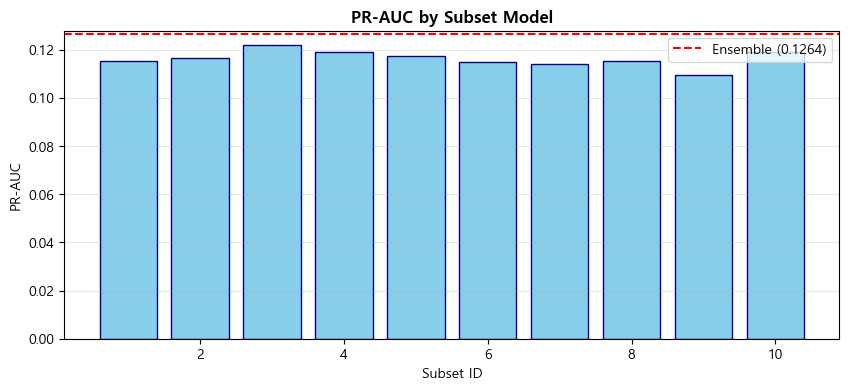

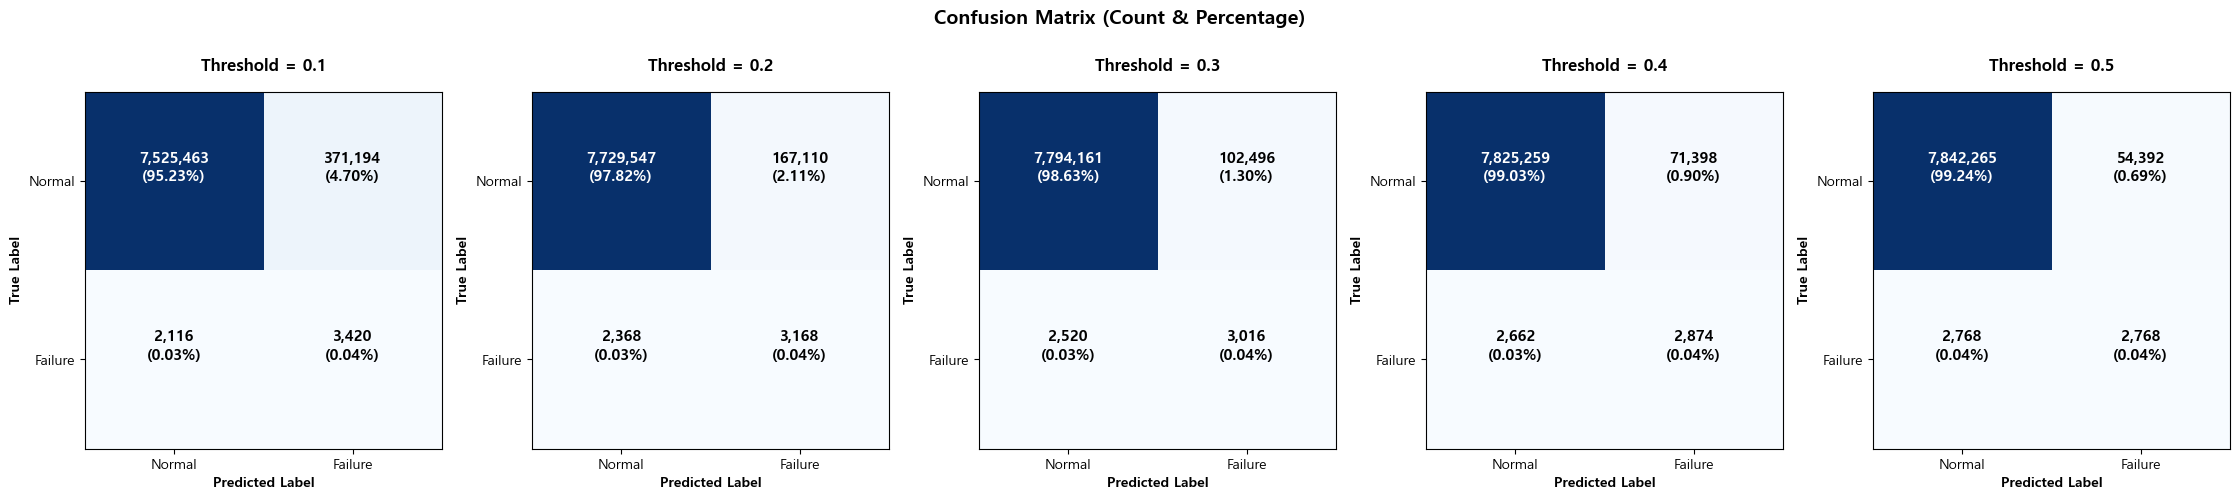

In [4]:
print('\n=========================================')
print('🏆 최종 선택된 최적 하이퍼파라미터')
print('=========================================')
for k, v in best_params.items():
    print(f'  - {k}: {v}')

print_ensemble_summary(ens_result)
plot_subset_prauc(ens_result)
plot_confusion_matrix(ens_result, cfg)

## 4. 최종 모델 및 설정 저장

In [5]:
import joblib, json
from pathlib import Path

SAVE_DIR = Path(cfg.MODEL_SAVE_DIR)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 서브셋 모델 저장
for i, model in enumerate(ens_result.models):
    path = SAVE_DIR / f'subset_{i:02d}.pkl'
    joblib.dump(model, path)
    print(f'  저장: {path}')

# 피처 목록 저장
feat_path = SAVE_DIR / 'feature_cols.json'
with open(feat_path, 'w', encoding='utf-8') as f:
    json.dump(result_dict['feature_cols'], f, ensure_ascii=False, indent=2)
print(f'  피처 목록: {feat_path}')

# best_params 저장
param_path = SAVE_DIR / 'best_params.json'
with open(param_path, 'w', encoding='utf-8') as f:
    json.dump(best_params, f, ensure_ascii=False, indent=2)
print(f'  파라미터 : {param_path}')

  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_00.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_01.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_02.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_03.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_04.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_05.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_06.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_07.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_08.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_09.pkl
  피처 목록: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\feature_cols.json
  파라미터 : c:\Workspace\06_ML_projdect